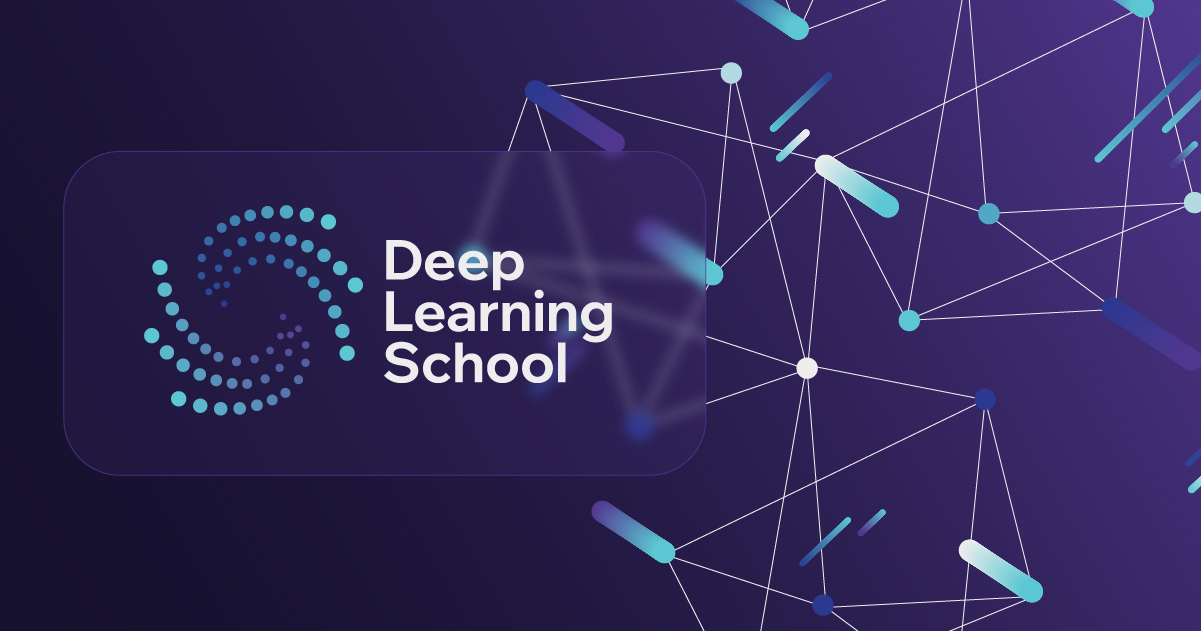


<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h3 style="text-align: center;"><b>Домашнее задание. Классификация изображений</b></h3>


# Домашнее задание. Классификация изображений

Сегодня вам предстоить помочь телекомпании FOX в обработке их контента. Как вы знаете, сериал "Симпсоны" идет на телеэкранах более 25 лет, и за это время скопилось очень много видеоматериала. Персоонажи менялись вместе с изменяющимися графическими технологиями, и Гомер Симпсон-2018 не очень похож на Гомера Симпсона-1989. В этом задании вам необходимо классифицировать персонажей, проживающих в Спрингфилде. Думаю, нет смысла представлять каждого из них в отдельности.



В нашем тесте будет 991 картинка, для которых вам будет необходимо предсказать класс.

## Шаг 1. Установка зависимостей

#### Установим необходимые библиотеки и проверим доступность CUDA

In [1]:
# we will verify that GPU is enabled for this notebook
# following should print: CUDA is available!  Training on GPU ...
#
# if it prints otherwise, then you need to enable GPU:
# from Menu > Runtime > Change Runtime Type > Hardware Accelerator > GPU

import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [2]:
# !nvidia-smi

In [3]:
import warnings
warnings.filterwarnings(action='ignore')

import pickle

from skimage import io
import random
import os
from sklearn.metrics import confusion_matrix

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path
import copy

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import WeightedRandomSampler
from collections import Counter

import torch.optim as optim
from torchvision import models

import pandas as pd
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties
from matplotlib import colors, pyplot as plt
%matplotlib inline


In [4]:
def set_seed(seed=42):
    """
    Фиксация всех источников случайности
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)
    
    # Для CUDA
    os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
    
    # Фиксация для DataLoader
    def seed_worker(worker_id):
        worker_seed = torch.initial_seed() % 2**32
        np.random.seed(worker_seed)
        random.seed(worker_seed)
    
    return seed_worker

# Фиксация случайности
seed_value = 42
seed_worker = set_seed(seed_value)

#### Проверим версии Python и библиотек
Посмотрим, какие версии установлены:

In [5]:
# !python --version
# from importlib.metadata import version
# for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
#     print(b + ' version: '+ version(b))

Сверим с версиями питона и библиотек, на которых работал эталонный ноутбук:

- Python 3.12.12
- torch version: 2.8.0+cu126
- torchvision version: 0.23.0+cu126
- tqdm version: 4.67.1
- matplotlib version: 3.10.0
- seaborn version: 0.13.2
- Pillow version: 11.3.0


 #### Определим константы, которые будем использовать в по ходу ноутбука

In [6]:
# root = '/content/'
root = 'content/'

# разные режимы датасета
DATA_MODES = ['train', 'val', 'test']

# работаем на видеокарте
DEVICE = torch.device("cuda")

#определим директории с тренировочными и тестовыми файлами
TRAIN_DIR = Path(root + 'train') #Path('./data/train/')
TEST_DIR = Path(root + 'testset') #Path('./data/testset')

# параметры нормировки изображений по трем каналам перед подачей в модель
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]

# все изображения будут масштабированы к размеру 224x224 px
RESCALE_SIZE = [224, 224]

## Шаг 2. Загрузка и обработка данных

#### Скачаем изображения по ссылке

In [7]:
# !mkdir content
# !mkdir models
# !mkdir subs

In [8]:
# !gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
# !gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1 -O content/journey-springfield.zip

In [9]:
# !unzip -q /content/journey-springfield.zip

Посмотрите на структуру файлов в папках train и testset.

В train лежат данные, которые мы будем использовать для обучения модели. Изображения персонажей разложены по папкам, которые названы по именам персонажей. Названия папок мы в дальнейшем будет использовать в качестве текстовых меток классов.

В testset находятся изображения, для которых вам надо будет сделать прогноз наиболее вероятного класса.


Для обращения к файлам сформируем списки имен файлов обучающей+валидационнной и тестовой выборок. Это полные имена, включающие путь к файлам.


In [10]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

Кодировать имена персонажей в числовые метки класса и обратно будем при помощи `LabelEncoder`.

Для train выборки сформируем список текстовых меток всех изображений - имя родительской директории, которая одновременно является и именем персонажа. Зададим числовые метки классов нашего энкодера при помощи метода `fit`.

Далее будем применять метод `transform` для преобразования текстовых меток в числовые, и метод `inverse_transform` для преобразования числовых меток в текстовые.


In [11]:
label_encoder = LabelEncoder()

train_val_labels = [path.parent.name for path in train_val_files]

label_encoder.fit(train_val_labels)

LabelEncoder()

Разделим train выборку на обучающую и валидационнную части. Для того, чтобы персонажи были пропорционально представлены в обучающей и валидационнной подвыборках, применим стратификацию по меткам класса.

In [12]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size=0.25,
                                          stratify=train_val_labels)

#### Создадим Datasets и Dataloaders

Полезная статья, которой мы вдохновились при создании класса `SimpsonsDataset`:
https://jhui.github.io/2018/02/09/PyTorch-Data-loading-preprocess_torchvision/


У нас есть набор файлов-картинок, которые требуется преобразовать в тензоры, и добавить к ним числовые метки классов. Реализуем это с помощью созданного нами класса `SimpsonsDataset`, который из списка файлов создаст необходимый нам Dataset.  

Будем действовать согласно инструкции из документации (https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html#creating-a-custom-dataset-for-your-files):
- наш класс будет наследовать от класса Dataset
- мы переопределим методы `__init__`, `__len__` и `__getitem__`, а также для удобства добавим несколько методов для загрузки и преобразования изображений.

Важно разобраться, что делает метод self.transform_images_to_tensors().

`Compose` объединяет последовательность следующих преобразований:
- `PILToTensor` конвертирует  `PIL Image` в тензор с параметрами в диапазоне $[0, 255]$ (как все пиксели в исходном изображении)
- `ToDtype` преобразует тензор в `FloatTensor` размера ($C \times H \times W$) со значениями пикселей в диапазоне $[0,1]$
- затем `Normalize` производится масштабирование:
$\text{input} = \frac{\text{input} - \text{mean}}{\text{std}} $, <br>      где константы mean и std - средние и дисперсии по каналам в датасете ImageNet
- наконец, `Resize` преобразует картинки к размеру $224 \times 224$ (в описании датасета указано, что картинки разного размера, так как брались напрямую с видео, поэтому следует привести их к одному размеру).

Сейчас аугментация не изображений не производится, поэтому для обучающих и валидационных/тестовых изображений производится одинаковая трансформация. В дальнейшем, если вы захотите добавить аугментацию, вы можете сделать это, например, модифицировав метод `transform_images_to_tensors`. Подробнее про трансформацию изображений вы можете почитать в документации: https://docs.pytorch.org/vision/main/transforms.html


In [13]:
class SimpsonsDataset(Dataset):
    def __init__(self, files, label_encoder, mode):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

    def __len__(self):
        return self.len_ # сейчас self.__len__() возвращает количество картинок, подаваемых на вход.
        # Если вы решите перевзвесить размеры категорий внутри класса -
        # не забудьте изменить вывод self.__len__()

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image):
      if self.mode == 'train':
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
            v2.Resize(RESCALE_SIZE),
          ])
      else:
        transform = v2.Compose([
            v2.PILToTensor(),
            v2.ToDtype(torch.float32, scale=True),
            v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
            v2.Resize(RESCALE_SIZE),
          ])

      tensor_transformed = transform(image)
      return(tensor_transformed)


In [14]:
train_dataset = SimpsonsDataset(train_files, label_encoder = label_encoder, mode='train')
val_dataset = SimpsonsDataset(val_files, label_encoder, mode='val')

In [15]:
batch_size = 128

In [16]:
# Для вопсроизводимости результатов
g = torch.Generator()
g.manual_seed(seed_value)


train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    worker_init_fn=seed_worker,
    generator=g,
    pin_memory=True
)

loaders = {'train': train_loader, 'val': val_loader}

#### Посмотрим на изображения персонажей

Напишем функцию для визуализации картинок. Это аналог Imshow, которая будет принимать на вход тензоры

In [17]:
def imshow(inp, title=None, plt_ax=plt, default=False):
    """Imshow для тензоров"""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt_ax.imshow(inp)
    if title is not None:
        plt_ax.set_title(title)
    plt_ax.grid(False)

Проверим, как работает наша функция. Возьмем один батч из лоадера и подадим на вход функции первый тензор из этого батча. Заодно посмотрим, как работает кодировщик меток класса.

Числовая метка класса: 20
Текстовая метка класса: ['lisa_simpson']


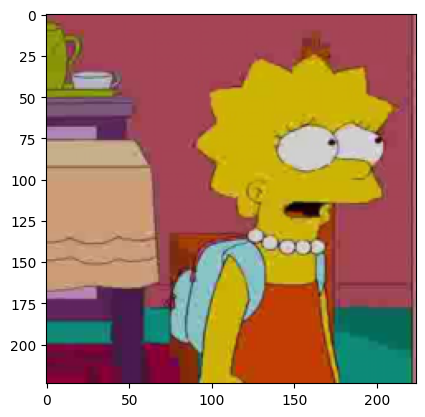

In [18]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0],])}")
imshow(image_tensor[0])

plt.show();

In [19]:
# uncomment if you have problem with pillow
# def register_extension(id, extension): Image.EXTENSION[extension.lower()] = id.upper()
# Image.register_extension = register_extension
# def register_extensions(id, extensions):
#     for extension in extensions: register_extension(id, extension)
# Image.register_extensions = register_extensions

Давайте посмотрим на наших героев внутри датасета.

In [21]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
    
  return None

**!** Обратите внимание, что возможно, датасет требует дополнительной фильтрации, так как лейблы не всегда точно соответствуют картинкам. Очистка датасета - это один из способов повысить качество модели. Этим можно будет заняться во второй части домашнего задания.

Запустим написанную функцию.

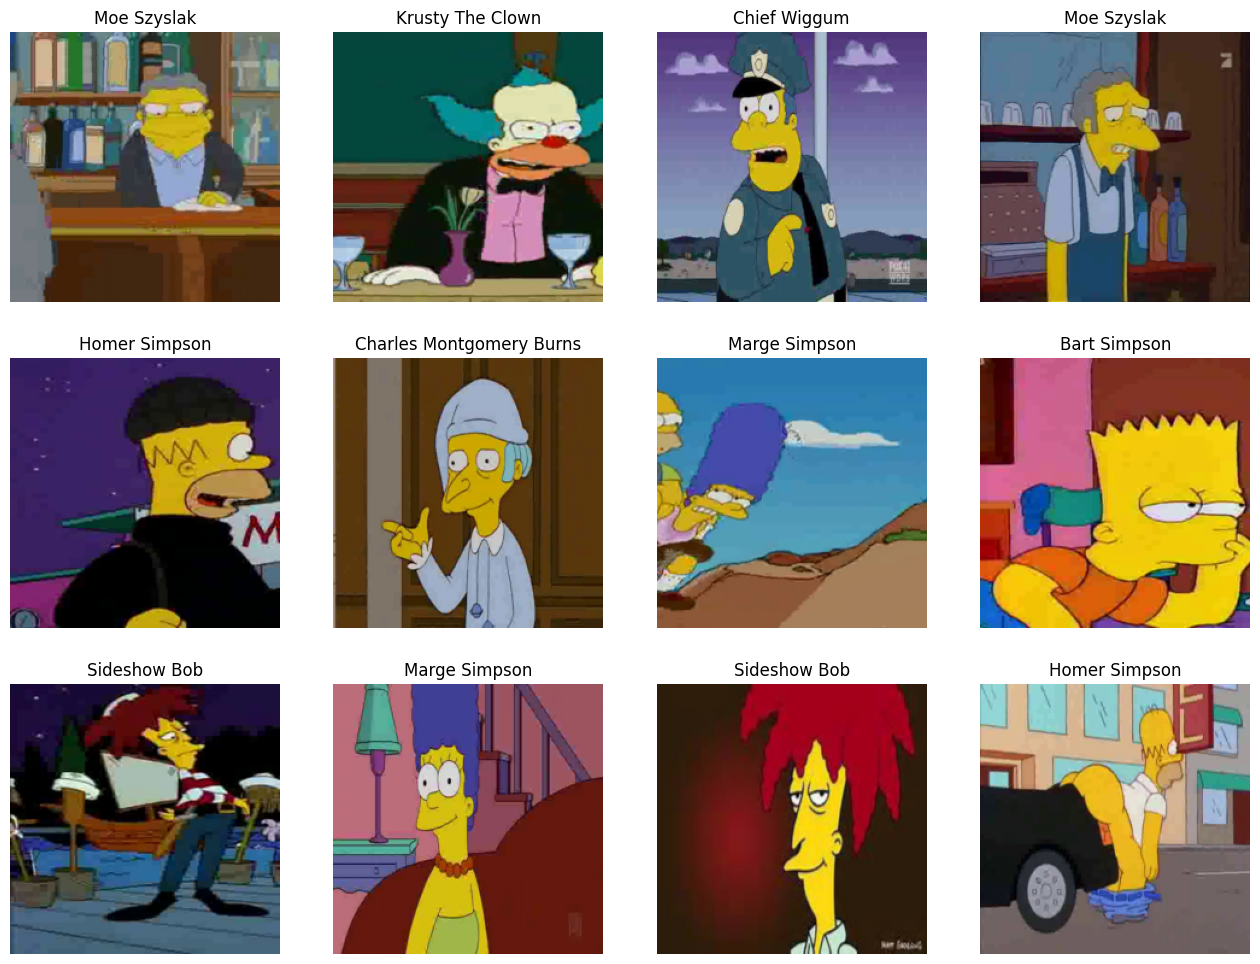

In [22]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

plt.show();

## Шаг 3. Построение нейросети (базовая реализация)

Запустить данную сеть будет вашим мини-заданием на первую неделю, чтобы было проще участвовать в соревновании.

Данная архитектура будет очень простой и нужна для того, чтобы установить базовое понимание и получить простенький сабмит на Kaggle.

О том, как работают свёртки подробней можно прочитать в документации Pytorch на функцию `Conv2d`:

https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html

Калькулятор свёрток:

https://madebyollin.github.io/convnet-calculator/

#### Модель

In [23]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [24]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

## Шаг 4. Функции для работы с моделью (базовая реализация)

Обратите внимание, что метрика, которую необходимо оптимизировать в конкурсе -- `f1-score`.

Ниже приводится код для вычисления целевой метрики.

In [25]:
from sklearn.metrics import f1_score
# пример расчета: f1 = f1_score(actual_labels, y_predicted, average='micro')

В этом задании может быть полезным сделать, чтобы функция валидации и, возможно, функция обучения на одной эпохе возвращали векторы/тензоры:
- предсказанного наиболее вероятного класса
- и фактических меток класса для каждого объекта.

Сама метрика f1, при этом, будет вычисляться не внутри функции, а вне ее, сопоставляя прогнозные и фактические значения, полученные из вывода функции.

Это поможет проанализировать, при предсказании каких классов модель ошибается чаще. Также такой подход может использоваться для обнаружения изображений, которые модель классифицирует неверно.

Для ускорения вычислений рекомендуется при работе с моделью проводить тензорные вычисления на GPU. Обращаем внимание, для этого необходимо, чтобы и данные, и модель находились на одном устройстве.

Ниже представлен код из предыдущего домашнего задания, который демонстрировал логику циклов обучения и валидации. Ниже в этот код добавлены строки комментарии, показывающие как переносить модель и данные на устройство.


```python
model.to(DEVICE)  # <- переносим модель на устройство DEVICE

for epoch in range(max_epochs):  
    # режим train
    model.train()  
    for x_batch, y_batch in train_dataloader:
        x_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        y_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        
        optimizer.zero_grad()
        outp = model(x_batch)
        loss = criterion(outp, y_batch)
        loss.backward()  
        optimizer.step()
        
        count_metrics(outp, y_batch)  # <-здесь, скорее всего, потребуется перенести данные на cpu, например с помощью метода cpu: metrics.cpu()
     
     # режим test/eval
     model.eval()  
     for x_batch, y_batch in val_dataloader:
        x_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        y_batch.to(DEVICE)  # <- переносим тензоры данных на устройство DEVICE
        
        with torch.no_grad():
            outp = model(x_batch)
            count_metrics(outp, y_batch) # <-здесь, скорее всего, потребуется перенести данные на cpu       
```

Напишите функции:
- для обучения модели на одной эпохе
- для валидации модели на одной эпохе
- для реализации полного цикла обучения

За основу можно взять функции, которые вы написали в предыдущем домашнем задании.

In [26]:
def get_model_name(model):
    """
    Получение имени модели
    """
    model_class_name = model.__class__.__name__
    
    if model_class_name.endswith('Module'):
        model_class_name = model_class_name[:-6]
    
    return model_class_name.lower()

In [27]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    """
    Обучение модели на одной эпохе
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        # Сохранение предсказаний для расчёта F1-score
        _, predicted = torch.max(outputs.data, dim=1)
        all_preds.append(predicted.cpu())
        all_labels.append(labels.cpu())

    # Объединение предсказаний
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Расчет метрик
    epoch_loss = running_loss / len(all_labels)
    epoch_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average='micro')

    return epoch_loss, epoch_f1, all_preds, all_labels

In [28]:
def eval_one_epoch(model, dataloader, criterion, device):
    """
    Валидация модели на одной эпохе
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Сохранение предсказаний для расчета F1-score
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

    # Объединение предсказаний
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Расчет метрик
    epoch_loss = running_loss / len(all_labels)
    epoch_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average='micro')

    return epoch_loss, epoch_f1, all_preds, all_labels

In [29]:
def train_model(model, num_epochs, loaders, optimizer, criterion, device=None):
    """
    Полный цикл обучения модели
    """
    history = {
        'train_loss': [],
        'train_f1': [],
        'val_loss': [],
        'val_f1': []
    }

    if device is None:
        device = torch.device(
            'cuda' if torch.cuda.is_available() else
            'mps' if torch.backends.mps.is_available() else
            'cpu')

    print(f'Training on {device}')

    best_val_f1 = 0
    best_epoch = 0
    best_model_state = None

    model_name = get_model_name(model)

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')

        # Обучение
        train_loss, train_f1, _, _ = train_one_epoch(
            model, loaders['train'], optimizer, criterion, device)

        # Валидация
        val_loss, val_f1, val_preds_epoch, val_labels_epoch = eval_one_epoch(
            model, loaders['val'], criterion, device)

        # Вывод
        print(f'Train Loss: {train_loss:.4f} | F1: {train_f1:.4f}')
        print(f'Val   Loss: {val_loss:.4f} | F1: {val_f1:.4f}')

        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        # Запоминание лучшей модели
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            print(f'Best F1!')

    # Загрузка и сохранение лучшей модели
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

        model_path = f'models/best_{model_name}.pth'
        torch.save({
            'model_state_dict': best_model_state,
            'val_f1': best_val_f1,
            'epoch': best_epoch,
            'history': history,
            'model_name': model_name
        }, model_path)

    print(f'\nBest Validation F1: {best_val_f1:.4f} on epoch {best_epoch}')

    return model, history

## Шаг 5. Применение модели к данным

#### Применение модели к данным

In [30]:
def set_seed(seed=42):
    """
    Фиксация всех источников случайности
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    os.environ['PYTHONHASHSEED'] = str(seed)

# Очистка кэша
torch.cuda.empty_cache()

# Фиксация случайности
set_seed(42)

In [31]:
# Функция потерь
criterion = nn.CrossEntropyLoss()

# Оптимизатор
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)

Запустите обучение сети

In [32]:
# Обучение модели

# Очищаем кэш
torch.cuda.empty_cache()

num_epochs = 11

model, history = train_model(
    model=model_simple_cnn,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE
)

Training on cuda

Epoch 1/11


Train Loss: 2.7213 | F1: 0.2389
Val   Loss: 2.1516 | F1: 0.4108
Best F1!

Epoch 2/11


Train Loss: 1.8240 | F1: 0.5002
Val   Loss: 1.6093 | F1: 0.5695
Best F1!

Epoch 3/11


Train Loss: 1.3147 | F1: 0.6349
Val   Loss: 1.2789 | F1: 0.6574
Best F1!

Epoch 4/11


Train Loss: 0.9711 | F1: 0.7284
Val   Loss: 1.0853 | F1: 0.7071
Best F1!

Epoch 5/11


...

Train Loss: 0.4553 | F1: 0.8670
Val   Loss: 1.0279 | F1: 0.7583

Epoch 8/11


Train Loss: 0.3352 | F1: 0.9020
Val   Loss: 1.0405 | F1: 0.7677
Best F1!

Epoch 9/11


Train Loss: 0.2475 | F1: 0.9257
Val   Loss: 1.0758 | F1: 0.7789
Best F1!

Epoch 10/11


Train Loss: 0.2022 | F1: 0.9381
Val   Loss: 1.2260 | F1: 0.7721

Epoch 11/11


Train Loss: 0.1592 | F1: 0.9492
Val   Loss: 1.3036 | F1: 0.7652

Best Validation F1: 0.7789 on epoch 9


(опционально) Постройте график динамики метрик модели по ходу обучения

In [33]:
# Построение графиков обучения модели

def plot_metrics(history, num_epochs):
    """
    Построение графиков обучения модели
    """

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

    # График loss
    ax1.plot(range(1, num_epochs+1), history['train_loss'], label='Train Loss', marker='o')
    ax1.plot(range(1, num_epochs+1), history['val_loss'], label='Val Loss', marker='s')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Losses')
    ax1.legend()
    ax1.grid(True)

    # График F1
    ax2.plot(range(1, num_epochs+1), history['train_f1'], label='Train F1', marker='o')
    ax2.plot(range(1, num_epochs+1), history['val_f1'], label='Val F1', marker='s')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.set_title('F1 Scores')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()

    # Лучшие метрики и эпохи
    best_val_loss = min(history['val_loss'])
    best_val_loss_epoch = history['val_loss'].index(best_val_loss) + 1

    best_val_f1 = max(history['val_f1'])
    best_val_f1_epoch = history['val_f1'].index(best_val_f1) + 1

    print(f'Best Validation Loss:   {best_val_loss:.4f} (Epoch {best_val_loss_epoch})')
    print(f'Best Validation F1:     {best_val_f1:.4f} (Epoch {best_val_f1_epoch})')
    
    return fig

Best Validation Loss:   0.9625 (Epoch 6)
Best Validation F1:     0.7789 (Epoch 9)


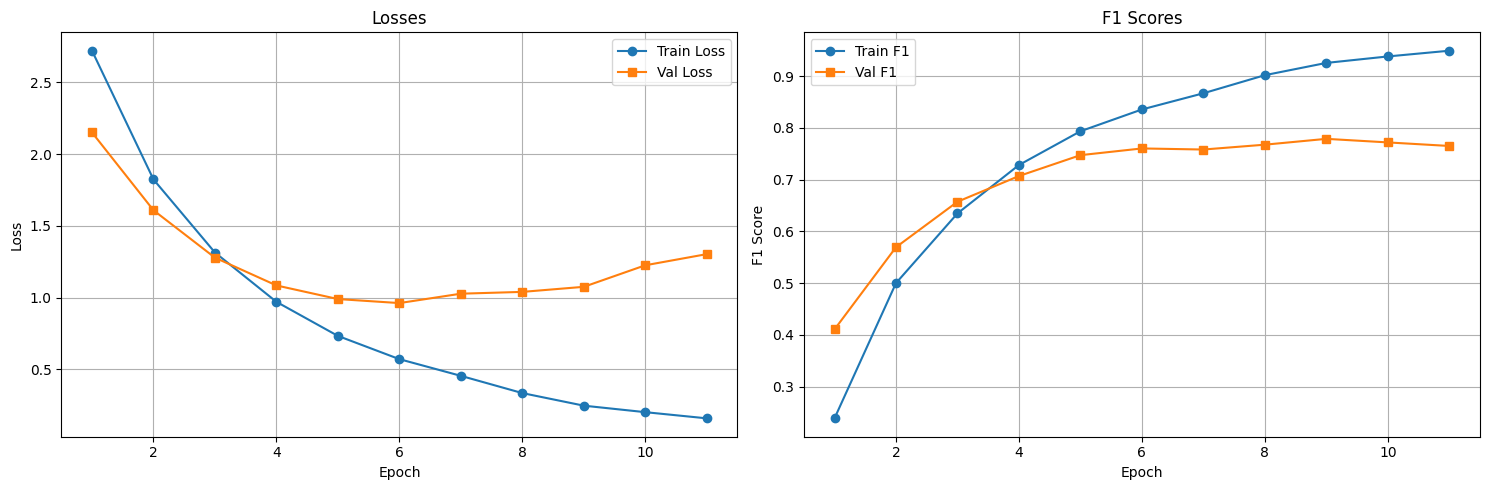

In [34]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

### Ну и что теперь со всем этим делать?

![alt text](https://www.indiewire.com/wp-content/uploads/2014/08/the-simpsons.jpg)

Сделаем классную визуализацию,  чтобы посмотреть насколько сеть уверена в своих ответах.

In [35]:
@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in axs.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # выводим изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

    # ниже представлен код для добавления на изображение подписи с вероятностью класса
    actual_text = "Actual : {}".format(img_label)


    font0 = FontProperties()
    font = font0.copy()

    # наша модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100 # берем максимальную вероятность класса
    y_pred = np.argmax(prob_pred) # берем числовую метку класса, для которого вероятность максимальна

    predicted_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

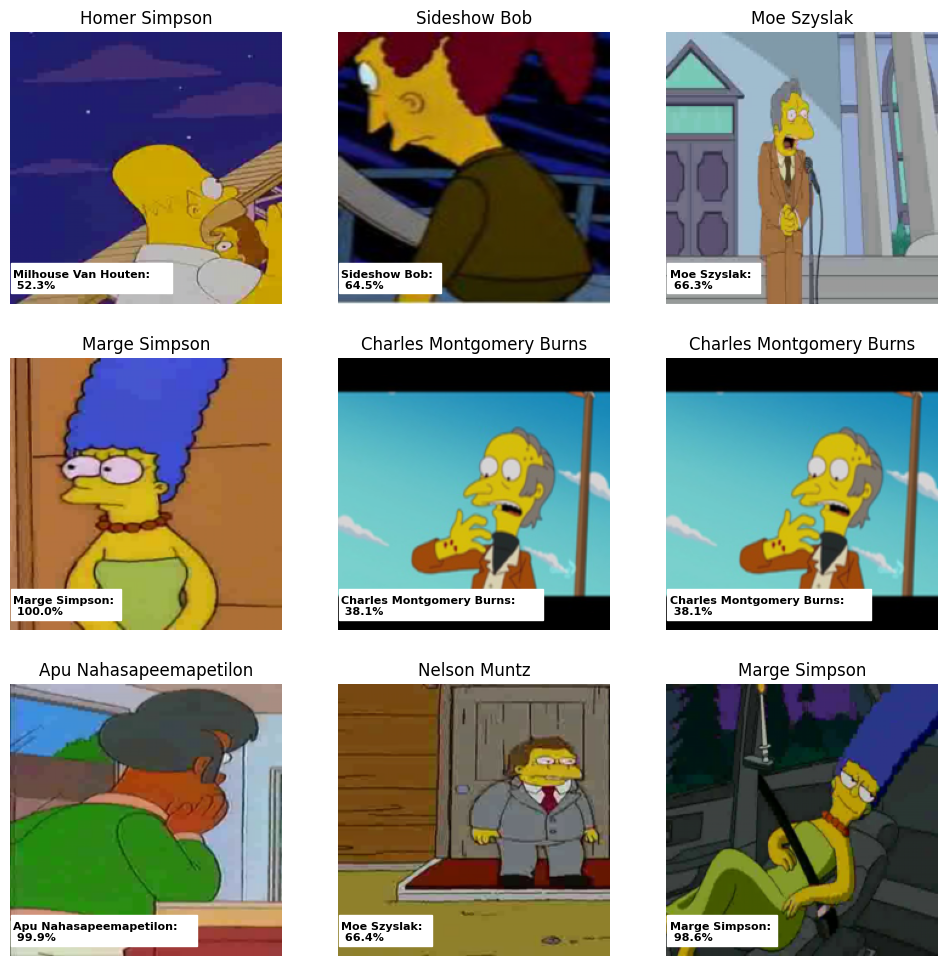

In [36]:
show_images2(n_rows = 3, n_cols = 3, dataset = val_dataset, model = model_simple_cnn)

plt.show();

## Шаг 6. Submit на Kaggle

![alt text](https://i.redd.it/nuaphfioz0211.jpg)

Создадим loader для тестовых данных

In [37]:
test_dataset = SimpsonsDataset(test_files, label_encoder = label_encoder, mode="test")
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [38]:
def predict(model, loader):
    model.eval()
    all_predictions = torch.tensor([]).to(DEVICE).int()
    print("Test mode...")
    for inputs in tqdm(loader):
        inputs = inputs.to(DEVICE)

        with torch.no_grad():
            outputs = model(inputs)

            predictions = outputs.argmax(-1).int()
            all_predictions = torch.cat((all_predictions, predictions), 0)
    return all_predictions.cpu()

Получаем предсказание меток классов для тестовых данных:

In [39]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)

Test mode...


100%|██████████| 16/16 [00:01<00:00, 10.37it/s]


и преобразуем их в текстовые метки:

In [40]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Загрузим пример файла для загрузки на Kaggle (проверьте путь, по которому у вас лежит файл sample_submission.csv и при необходимости скорректируйте путь в коде ниже):

In [41]:
sample_submission = pd.read_csv(root + 'sample_submission.csv')
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [42]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [43]:
# TODO : сделайте сабмит (это важно, если Вы не справляетесь, но дошли до этой ячейки, то сообщите в чат и Вам помогут)

In [44]:
# my_submission.to_csv('simple_cnn_baseline.csv', index=False)

## Приключение?

А теперь самое интересное, мы сделали простенькую сверточную сеть и смогли отправить сабмит, но получившийся score нас явно не устраивает. Надо с этим что-то сделать.

Вам предлагается творческая и исследовательская свобода в том, как вы будете улучшать score модели. Вот некоторые направления, которые вы, возможно, захотите попробовать:
1. Работа с датасетом:
* Попробуйте увеличить разнообразие обучающей выборки при помощи аугментации ([ссылка 1](https://habr.com/ru/companies/smartengines/articles/264677/), [ссылка 2](https://www.geeksforgeeks.org/python-data-augmentation/));
* Используя результаты функции eval_one_epoch, вы можете посмотреть, как метрика f1-score внутри класса связана с размером самого класса в обучающей выборке. Скорее всего, вы заметите прямую зависимость. Решением может быть увеличение размеров слабо представленных классов. Сделать это можно, вручную добавив этот функционал в SimpsonsDataset или воспользовавшись инструментом WeightedRandomSampler.

* Также вы можете изучить, какие изображения модель классифицирует неверно. Можно просто посмотреть неверно классифицированные изображения в валидационном датасете. Можно попробовать более фундаментальный подход - создать dataloader из всех изображений обучающей и валидационной выборки в SimpsonsDataset c режимом 'val', прогнать данные через обученную модель simple_cnn. Более того, можно обучить несколько моделей с разной архитектурой, и прогнать объединенный датасет через все эти модели - и выделить те изображения, в классификации которых ошиблись несколько моделей.

* Это поможет понять, как качество и чистота исходных данных влияет на результаты обучения модели. Если вы обнаружите ошибки в simpsons_dataset и решите их исправить или удалить некоторые изображения из обучающей выборки - сделайте это в ноутбуке, чтобы при проверке можно было повторить результаты работы вашего кода.  

2. Работа с архитектурой сети:
* учим дольше и изменяем (подбираем) гиперпараметры: learning rate, batch size, нормализация картинки и вот это всё;
* добавление/удаление свёрточных и полносвязных слоёв;
* А еще есть где пулинги и батч-норм!

3. Применение техник, описанных в предыдущих пунктах, позволяет добиться довольно высоких результатов. Но вы можете попробовать файнтютинг и трансферлёнинг:
* ну разве это deep learning? Вот ResNet и Inception, которые можно зафайнтьюнить под наши данные, вот это я понимаю (можно и обучить в колабе, а можно и [готовые](https://github.com/Cadene/pretrained-models.pytorch) скачать).

4. Улучшение оптимизации:
* ну разве Адам наше все? [adamW](https://www.fast.ai/2018/07/02/adam-weight-decay/) для практика, [статейка для любителей](https://openreview.net/pdf?id=ryQu7f-RZ) (очень хороший анализ), [наши ](https://github.com/MichaelKonobeev/adashift/) эксперименты для заинтересованных.

5. Наконец, возможно, стоит подумать об ансамблях


Надеюсь, что у Вас получится!

### План

In [ ]:
# 1) Базовая реализация
# 2) Дизбаланс классов - WeightedRandomSampler и взвешенная loss-функция
# 3) Шедулер + оптимизатор AdamW - AdamW с CosineAnnealingLR scheduler
# 4) Аугментации - простые преобразования и MixUp-аугментация
# 5) Какие классы выбиваются по метике - использовать WeightedRandomSampler
# 6) Предобученные модели - от простой CNN до предобученного ResNet-152

### Подготовка данных (custom class SimpsonsDataset)

Создадим аугментации, подходящие для датасета с персонажами мульсерииала. <br>
В них будут входить простые аугментации, например: отражение по горизонтали, небольшие повороты, незначительные изменения цвета, изменения масштаба, изменения пропорций, кроп.

In [ ]:
class SimpsonsDataset_custom(Dataset):
    def __init__(self, files, label_encoder, mode, augmentation_type='basic', class_threshold=None):
        super().__init__()
        # список файлов для загрузки
        self.files = sorted(files)
        # режим работы
        self.mode = mode
        if self.mode not in DATA_MODES:
            print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
            raise NameError

        self.label_encoder = label_encoder
        self.len_ = len(self.files)

        self.augmentation_type = augmentation_type
        self.class_threshold = class_threshold

        if self.mode == 'train' and class_threshold is not None:
            train_labels = [path.parent.name for path in self.files]
            self.class_counts = Counter(train_labels)
            
            # Распределение по редким и обычным классам
            self.rare_classes = [cls for cls, count in self.class_counts.items()
                                 if count < self.class_threshold]
            self.common_classes  = [cls for cls, count in self.class_counts.items()
                                    if count >= self.class_threshold]
        else:
            self.class_counts = None

    def __len__(self):
        return self.len_

    def __getitem__(self, index):
        x = self.load_image(self.files[index])
        x = self.transform_images_to_tensors(x, index)

        if self.mode == 'test':
            return x
        else:
            path = self.files[index]
            y = self.label_encoder.transform([path.parent.name,]).item()
            return x, y

    # принимает путь к файлу изображения и возвращает само изображение
    def load_image(self, file):
        image = Image.open(file)
        image.load()
        return image

    # преобразует изображение в тензор
    def transform_images_to_tensors(self, image, index=None):
        if self.mode == 'train':
            # Тип аугментации
            if self.class_counts is not None and index is not None:
                # Условная аугментация, если условная аугментация по редких и обычных классов
                class_name = self.files[index].parent.name
                count = self.class_counts[class_name]
                if count < self.class_threshold:
                    aug_type = 'custom_4'   # для редких классов - аугментация сложнее
                else:
                    aug_type = 'custom_1'   # для обычных классов - аугментация проще
            else:
                aug_type = self.augmentation_type

            if aug_type == 'basic':                         # F1: 0.7961 on epoch 8
                transform = v2.Compose([
                    v2.Resize(RESCALE_SIZE),
                    v2.PILToTensor(),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD), # параметры, вычисленные на датасете ImageNet
                ])

            elif aug_type == 'custom_1':                    # F1: 0.8267 on epoch 11
                transform = v2.Compose([
                    v2.Resize(RESCALE_SIZE),
                    v2.RandomHorizontalFlip(p=0.5),         # отражение
                    v2.RandomRotation(degrees=8),           # поворот
                    v2.PILToTensor(),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                ])

            elif aug_type == 'custom_2':                    # F1: 0.8259 on epoch 11
                transform = v2.Compose([
                    v2.Resize(RESCALE_SIZE),
                    v2.RandomHorizontalFlip(p=0.5),         # отражение
                    v2.RandomRotation(degrees=8),           # поворот
                    v2.ColorJitter(                         # изменение цвета
                        brightness=0.10,
                        contrast=0.10,
                        saturation=0.05
                    ),
                    v2.PILToTensor(),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                ])

            elif aug_type == 'custom_3':                    # F1: 0.8267 on epoch 11
                transform = v2.Compose([
                    v2.Resize(RESCALE_SIZE),
                    v2.RandomHorizontalFlip(p=0.5),
                    v2.RandomRotation(degrees=8),
                    v2.RandomResizedCrop(                   # случайный кроп и масштаб
                        size=RESCALE_SIZE,
                        scale=(0.8, 1.0),                   # от 80% до 100%
                        ratio=(0.9, 1.1)                    # изменение пропорций
                    ),
                    v2.ColorJitter(
                        brightness=0.1,
                        contrast=0.1
                    ),
                    v2.PILToTensor(),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                ])

            elif aug_type == 'custom_4':                    # F1: 0.8403 on epoch 11
                transform = v2.Compose([
                    v2.Resize(RESCALE_SIZE),
                    v2.RandomHorizontalFlip(p=0.5),
                    v2.RandomRotation(degrees=8),
                    v2.RandomResizedCrop(                   # случайный кроп и масштаб
                        size=RESCALE_SIZE,
                        scale=(0.85, 1.0),                  # от 85% до 100%
                        ratio=(0.95, 1.05)                  # изменение пропорций
                    ),
                    v2.ColorJitter(
                        brightness=0.1,
                        contrast=0.1
                    ),
                    v2.PILToTensor(),
                    v2.ToDtype(torch.float32, scale=True),
                    v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                ])
                
        else:
            transform = v2.Compose([
                v2.Resize(RESCALE_SIZE),
                v2.PILToTensor(),
                v2.ToDtype(torch.float32, scale=True),
                v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
                
            ])

        tensor_transformed = transform(image)
        return(tensor_transformed)


### Создание даталоадеров, аугментации MixUp

In [47]:
def create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type='custom_1',
    class_threshold=None,
    use_sampler=True,
    sampler_oversample=2.0,
    batch_size=128,
    seed=42
):
    '''
    Создание DataLoaders с настраиваемыми параметрами
    '''
    set_seed(seed)
    seed_worker = set_seed(seed)
    
    # Создлание датасетов
    train_dataset = SimpsonsDataset_custom(
        train_files, 
        label_encoder=label_encoder, 
        mode='train', 
        augmentation_type=augmentation_type,
        class_threshold=class_threshold
    )
    
    val_dataset = SimpsonsDataset_custom(
        val_files, 
        label_encoder=label_encoder, 
        mode='val'
    )
    
    # Вычисление веса для sampler и loss
    train_labels = [path.parent.name for path in train_files]
    class_counts = Counter(train_labels)
    
    # Создание sampler
    if use_sampler:
        sample_weights = [1.0 / class_counts[path.parent.name] for path in train_files]
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=int(len(sample_weights) * sampler_oversample),
            replacement=True
        )
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, sampler=sampler,
            worker_init_fn=seed_worker, pin_memory=True
        )
        print(f'Sampler: on (oversample={sampler_oversample})')
    else:
        train_loader = DataLoader(
            train_dataset, batch_size=batch_size, shuffle=True,
            worker_init_fn=seed_worker, pin_memory=True
        )
        print(f'Sampler: off')
    
    val_loader = DataLoader(
        val_dataset, batch_size=batch_size, shuffle=False,
        worker_init_fn=seed_worker, pin_memory=True
    )
    
    loaders = {'train': train_loader, 'val': val_loader}
    
    # Вычисление веса для loss функции
    unique_labels = np.array(label_encoder.classes_)
    class_weights = compute_class_weight('balanced', classes=unique_labels, y=train_labels)
    class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
    
    return loaders, class_weights_tensor, class_counts

In [ ]:
def mixup_data(x, y, alpha=0.2):
    """
    Реализация MixUp для глубоких сетей
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    # Случайная перестановка индексов в батче
    batch_size = x.size()[0]
    index = torch.randperm(batch_size).to(x.device)

    # Создание смешанного изображения (λ · изображение_1 + (1-λ) · изображение_2)
    mixed_x = lam * x + (1 - lam) * x[index]

    # Создание смешанных меток
    y_a, y_b = y, y[index]
    
    return mixed_x, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """
    Функция потерь для MixUp
    """
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

### Получение названия модели, предсказание

In [49]:
def get_model_name_with_params(model, augmentation_type, class_threshold, use_sampler, use_class_weights, use_mixup, batch_size):
    """
    Получение имени модели (улучшенная версия)
    """
    model_name = get_model_name(model)
    
    # Добавление параметрыов в имя
    params = []
    params.append(f"aug_{augmentation_type}")
    
    if class_threshold is not None:
        params.append(f"thr_{class_threshold}")
    else:
        params.append("no_thr")
    
    params.append(f"sampler_{'on' if use_sampler else 'off'}")
    params.append(f"weights_{'on' if use_class_weights else 'off'}")
    params.append(f"mixup_{'on' if use_mixup else 'off'}")
    params.append(f"bs_{batch_size}")
    
    return f"{model_name}_{'_'.join(params)}"

In [ ]:
def make_submission(model, test_files, label_encoder, model_name, device=DEVICE):
    """
    Ппредсказание и сохраняние сабмита
    """
    # Загрузка тестового датасета и создание даталоадера
    test_dataset = SimpsonsDataset_custom(test_files, label_encoder, mode='test')
    test_loader = DataLoader(test_dataset, shuffle=False, batch_size=64)
    
    # Предсказание
    model.eval()
    all_predictions = []
    
    with torch.no_grad():
        for inputs in tqdm(test_loader, desc='Test'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions = outputs.argmax(-1).cpu().numpy()
            all_predictions.extend(predictions)
    
    # Преобразование предсканий меток в текстовые местки
    predicted_text_labels = label_encoder.inverse_transform(all_predictions)
    
    # Создание сабмита
    my_submission = pd.DataFrame({
        'Id': [path.name for path in test_files], 
        'Expected': predicted_text_labels
    })
    
    # Сохранение сабмита

    submission_path = f'subs/submission_{model_name}.csv'
    my_submission.to_csv(submission_path, index=False)
    print(f'Submission saved: {submission_path}')
    
    return my_submission

### Функции обучения модели (custom)

In [51]:
def train_one_epoch(model, dataloader, optimizer, criterion, device, use_mixup=False, mixup_alpha=0.2):
    """
    Обучение модели на одной эпохе
    """
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(dataloader, desc='Training', leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        
        if use_mixup:
            # MixUp аугментация
            mixed_x, y_a, y_b, lam = mixup_data(images, labels, mixup_alpha)
            outputs = model(mixed_x)
            loss = mixup_criterion(criterion, outputs, y_a, y_b, lam)
            
            # Сохранение предсказаний для расчёта F1-score
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Сохранение предсказаний для расчёта F1-score
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)


    # Объединение предсказаний
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Расчет метрик
    epoch_loss = running_loss / len(all_labels)
    epoch_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average='micro')

    return epoch_loss, epoch_f1, all_preds, all_labels

In [52]:
def eval_one_epoch(model, dataloader, criterion, device):
    """
    Валидация модели на одной эпохе
    """
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc='Validation', leave=False):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            # Сохранение предсказаний для расчета F1-score
            _, predicted = torch.max(outputs.data, dim=1)
            all_preds.append(predicted.cpu())
            all_labels.append(labels.cpu())

    # Объединение предсказаний
    all_preds = torch.cat(all_preds)
    all_labels = torch.cat(all_labels)

    # Расчет метрик
    epoch_loss = running_loss / len(all_labels)
    epoch_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average='micro')

    return epoch_loss, epoch_f1, all_preds, all_labels

In [53]:
def train_model(model, num_epochs, loaders, optimizer, criterion, device=None, 
                                  scheduler=None, use_mixup=False, mixup_alpha=0.2,
                                  augmentation_type='custom_1', class_threshold=None,
                                  use_sampler=False, use_class_weights=False, batch_size=128):
    """
    Полный цикл обучения модели
    """
    history = {
        'train_loss': [],
        'train_f1': [],
        'val_loss': [],
        'val_f1': []
    }

    if device is None:
        device = torch.device(
            'cuda' if torch.cuda.is_available() else
            'mps' if torch.backends.mps.is_available() else
            'cpu')

    print(f'Training on {device}')

    best_val_f1 = 0
    best_epoch = 0
    best_model_state = None

    # Получение названия модели
    model_name = get_model_name_with_params(
        model, augmentation_type, class_threshold, 
        use_sampler, use_class_weights, use_mixup, batch_size
        )

    for epoch in range(num_epochs):
        print(f'\nEpoch {epoch+1}/{num_epochs}')

        # Обучение (с MixUp, если есть)
        train_loss, train_f1, _, _ = train_one_epoch(
            model, loaders['train'], optimizer, criterion, device,
            use_mixup=use_mixup, mixup_alpha=mixup_alpha)

        # Валидация (без MixUp)
        val_loss, val_f1, _, _ = eval_one_epoch(
            model, loaders['val'], criterion, device)

        # Вывод
        print(f'Train Loss: {train_loss:.4f} | F1: {train_f1:.4f}')
        print(f'Val   Loss: {val_loss:.4f} | F1: {val_f1:.4f}')

        # Обновление scheduler
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_f1)
            else:
                scheduler.step()

        # Сохранение истории
        history['train_loss'].append(train_loss)
        history['train_f1'].append(train_f1)
        history['val_loss'].append(val_loss)
        history['val_f1'].append(val_f1)

        # Сохранение модели на каждой 5-ой эпохе
        if (epoch + 1) % 5 == 0:
            checkpoint_path = f'models/{model_name}_epoch_{epoch+1}.pth'
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_f1': train_f1,
                'val_f1': val_f1,
                'history': history
            }, checkpoint_path)

        # Запоминание лучшей модели
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())
            print(f'Best F1!')

    # Загрузка и сохранение лучшей модели
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

        best_model_path = f'models/best_{model_name}.pth'
        torch.save({
            'model_state_dict': best_model_state,
            'val_f1': best_val_f1,
            'epoch': best_epoch,
            'history': history,
            'model_name': model_name,
            'params': {
                'augmentation_type': augmentation_type,
                'class_threshold': class_threshold,
                'use_sampler': use_sampler,
                'use_class_weights': use_class_weights,
                'use_mixup': use_mixup,
                'batch_size': batch_size
            }
        }, best_model_path)

    print(f'\nBest Validation F1: {best_val_f1:.4f} on epoch {best_epoch}')

    return model, history, model_name

### Выбор набора аугментаций

Обучим простую модель cnn с разными наборами аугментаций и выберем наиболее подходящие.

In [ ]:
# Список вариантов аугментации
augmentation_types = ['basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4']

# Фиксация случайности
seed_value = 42
seed_worker = set_seed(seed_value)

# Словарь для хранения результатов
results = {}

for aug_type in augmentation_types:
    print(f"\n\naugmentation_type = '{aug_type}'")
    
    # Фиксация случайности
    set_seed(seed_value)
    seed_worker = set_seed(seed_value)
    
    # Создание датасета
    train_dataset = SimpsonsDataset_custom(
        train_files, 
        label_encoder=label_encoder, 
        mode='train', 
        augmentation_type=aug_type
    )
    
    val_dataset = SimpsonsDataset_custom(
        val_files, 
        label_encoder=label_encoder, 
        mode='val'
    )
    
    # DataLoader
    batch_size = 128
    g = torch.Generator()
    g.manual_seed(seed_value)
    
    train_loader = DataLoader(
        train_dataset, 
        batch_size=batch_size, 
        shuffle=True,
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True
    )
    
    val_loader = DataLoader(
        val_dataset, 
        batch_size=batch_size, 
        shuffle=False,
        worker_init_fn=seed_worker,
        generator=g,
        pin_memory=True
    )
    
    loaders = {'train': train_loader, 'val': val_loader}
    
    # Параметры обучения
    num_epochs = 11
    num_classes = len(label_encoder.classes_)
    
    # Модель
    model = SimpleCnn(n_classes=num_classes).to(DEVICE).float()
    
    # Оптимизатор
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # Очищаем кэш
    torch.cuda.empty_cache()   
     
    # Обучение
    model, history, model_name = train_model(
        model=model,
        num_epochs=num_epochs,
        loaders=loaders,
        optimizer=optimizer,
        criterion=criterion,
        device=DEVICE
    )
    
    # Сохранение лучшиего F1 для каждой модели
    best_f1 = max(history['val_f1'])
    results[aug_type] = best_f1

for aug_type, best_f1 in results.items():
    print(f'\n{aug_type}: Best F1 = {best_f1:.4f}')

# basic:    Best F1 = 0.7961
# custom_1: Best F1 = 0.8267
# custom_2: Best F1 = 0.8259
# custom_3: Best F1 = 0.8267
# custom_4: Best F1 = 0.8403



augmentation_type = 'basic'
Training on cuda

Epoch 1/11


Train Loss: 2.7443 | F1: 0.2338
Val   Loss: 2.1320 | F1: 0.4287
Best F1!

Epoch 2/11


Train Loss: 1.8297 | F1: 0.4944
Val   Loss: 1.5604 | F1: 0.5676
Best F1!

Epoch 3/11


Train Loss: 1.2699 | F1: 0.6492
Val   Loss: 1.1935 | F1: 0.6756
Best F1!

Epoch 4/11


Train Loss: 0.8962 | F1: 0.7520
Val   Loss: 1.0187 | F1: 0.7310
Best F1!

Epoch 5/11


...

Train Loss: 0.6589 | F1: 0.8129
Val   Loss: 0.7112 | F1: 0.8133
Best F1!

Epoch 8/11


Train Loss: 0.5840 | F1: 0.8337
Val   Loss: 0.7121 | F1: 0.8128

Epoch 9/11


Train Loss: 0.5063 | F1: 0.8580
Val   Loss: 0.6614 | F1: 0.8282
Best F1!

Epoch 10/11


Train Loss: 0.4580 | F1: 0.8720
Val   Loss: 0.6564 | F1: 0.8344
Best F1!

Epoch 11/11


Train Loss: 0.4181 | F1: 0.8806
Val   Loss: 0.6619 | F1: 0.8403
Best F1!

Best Validation F1: 0.8403 on epoch 11

basic: Best F1 = 0.7961

custom_1: Best F1 = 0.8267

custom_2: Best F1 = 0.8259

custom_3: Best F1 = 0.8267

custom_4: Best F1 = 0.8403


Вывод: исследуемые наборы агументаций довольно хорошо повышает скор, занчит мы будем использовать данные аугментации в дальнейшем.

### Баланс классов

Посмотрим на распределение количества образцов (изображений) по классам. <br>
Сравним со средним значением количества образцов.

Всего изображений: 20933
Всего классов: 42


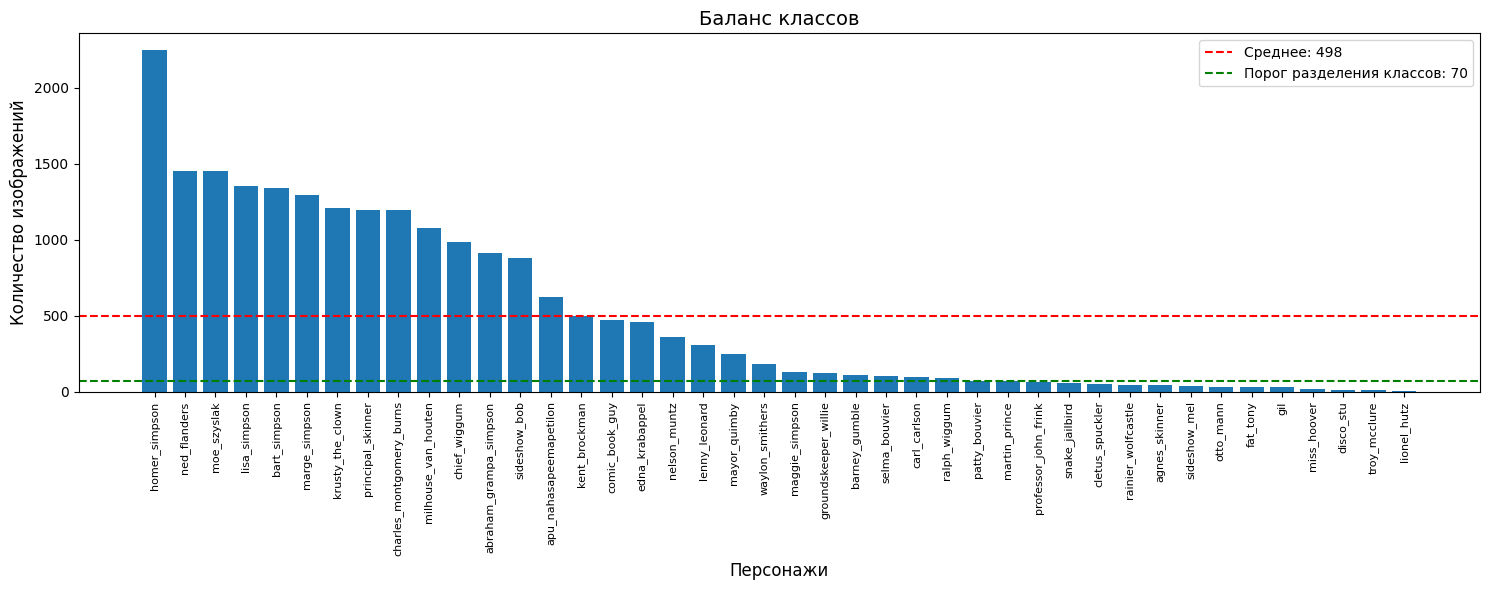

In [55]:
# Все метки классов
all_labels = [path.parent.name for path in train_val_files]

# Количество меток каждого класса
class_counts = Counter(all_labels)

# Сортировка по убыванию
class_counts_sorted = dict(sorted(class_counts.items(), key=lambda x: x[1], reverse=True))

# Результаты
print('Всего изображений:', len(all_labels))
print('Всего классов:', len(class_counts))

class_threshold = 70  

plt.figure(figsize=(15, 6))
classes = list(class_counts_sorted.keys())
counts = list(class_counts_sorted.values())

# Визуализация
plt.bar(classes, counts)
plt.xticks(rotation=90, fontsize=8)
plt.xlabel('Персонажи', fontsize=12)
plt.ylabel('Количество изображений', fontsize=12)
plt.title('Баланс классов', fontsize=14)

plt.axhline(y=sum(counts)/len(counts), color='red', linestyle='--', 
            label=f'Среднее: {sum(counts)/len(counts):.0f}')

plt.axhline(class_threshold, color='green', linestyle='--', 
            label=f'Порог разделения классов: {class_threshold}')

plt.legend()
plt.tight_layout()

plt.show();

Наблюдается сильный дисбаланс классов. Используем WeightedRandomSampler (реализовано в create_dataloaders). <br>
А также интуитивно подберем class_threshold (порог разбиения по количеству образцов на редкие и обычные классы). Для редких будем использовать усиленную аугментацию.

### Про технику MixUp

Реализовано в отдельной функции mixup_data, применяется функции train_one_epoch.

MixUp (смешивание) - это метод аугментации данных, при котором создаются искусственные обучающие примеры путем линейной комбинации двух случайных изображений и их меток. <br>
Смешанное_изображение = λ · изображение_1 + (1-λ) · изображение_2 <br>
Смешанная_метка       = λ · метка_1 + (1-λ) · метка_2, <br>
где λ ~ Beta(α, α) (из бета-распределения). <br>
Чтобы случайно сопоставить каждое изображение с другим из того же батча. <br><br>
Пример: <br>
Исходные данные (batch_size=3) <br>
x = [изобр_A, изобр_B, изобр_C] <br>

index = [2, 0, 1]  # случайная перестановка <br>

x[index] = [изобр_C, изобр_A, изобр_B] <br>

Для первого изображения в батче: <br>
lam = 0.7 <br>
mixed_x[0] = 0.7 * изобр_A + 0.3 * изобр_C <br>

Для второго: <br>
mixed_x[1] = 0.7 * изобр_B + 0.3 * изобр_A <br>

Для третьего: <br>
mixed_x[2] = 0.7 * изобр_C + 0.3 * изобр_B <br>

Таким образом MixUp сглаживает границы между классами. Таким образом MixUp не однозначно делит изображение на классы, а относит изображение к классам с разной степенью уверености.

### Обучение simple_cnn с различными параметрами

Для начала попробуем несколько вариантов наборов параметров для обучения модели и создания даталоадеров.

simple_cnn: class_threshold = 70, use_sampler = True, sampler_oversample = 2.0, use_class_weights = True, use_mixup = False

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_1'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = 70  # None - отключено, число - порог
num_classes = len(label_encoder.classes_)
use_sampler = True # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = True # взвешенная функция потерь
use_mixup = True # MixUp аугментация
mixup_alpha = 0.2 # коэффициент смешивания двух изображений
batch_size = 128  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 16

In [57]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: on (oversample=2.0)


In [58]:
# Модель
model_simple_cnn = SimpleCnn(n_classes=num_classes).to(DEVICE).float()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr=1e-3)

# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Взвешенная CrossEntropyLoss


In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model_simple_cnn,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.6765 on epoch 16

Training on cuda

Epoch 1/16


Train Loss: 2.9229 | F1: 0.1306
Val   Loss: 2.8023 | F1: 0.2853
Best F1!

Epoch 2/16


Train Loss: 1.9677 | F1: 0.2199
Val   Loss: 2.5871 | F1: 0.3936
Best F1!

Epoch 3/16


Train Loss: 1.7709 | F1: 0.3093
Val   Loss: 2.1646 | F1: 0.5055
Best F1!

Epoch 4/16


Train Loss: 1.5303 | F1: 0.3299
Val   Loss: 2.0207 | F1: 0.5197
Best F1!

Epoch 5/16


...

Train Loss: 0.9476 | F1: 0.4037
Val   Loss: 1.5444 | F1: 0.6238

Epoch 13/16


Train Loss: 0.9716 | F1: 0.4331
Val   Loss: 1.4819 | F1: 0.6708
Best F1!

Epoch 14/16


Train Loss: 0.8938 | F1: 0.4906
Val   Loss: 1.4475 | F1: 0.6748
Best F1!

Epoch 15/16


Train Loss: 0.9372 | F1: 0.4091
Val   Loss: 1.4456 | F1: 0.6704

Epoch 16/16


Train Loss: 0.8453 | F1: 0.4634
Val   Loss: 1.4408 | F1: 0.6765
Best F1!

Best Validation F1: 0.6765 on epoch 16


Best Validation Loss:   1.4408 (Epoch 16)
Best Validation F1:     0.6765 (Epoch 16)


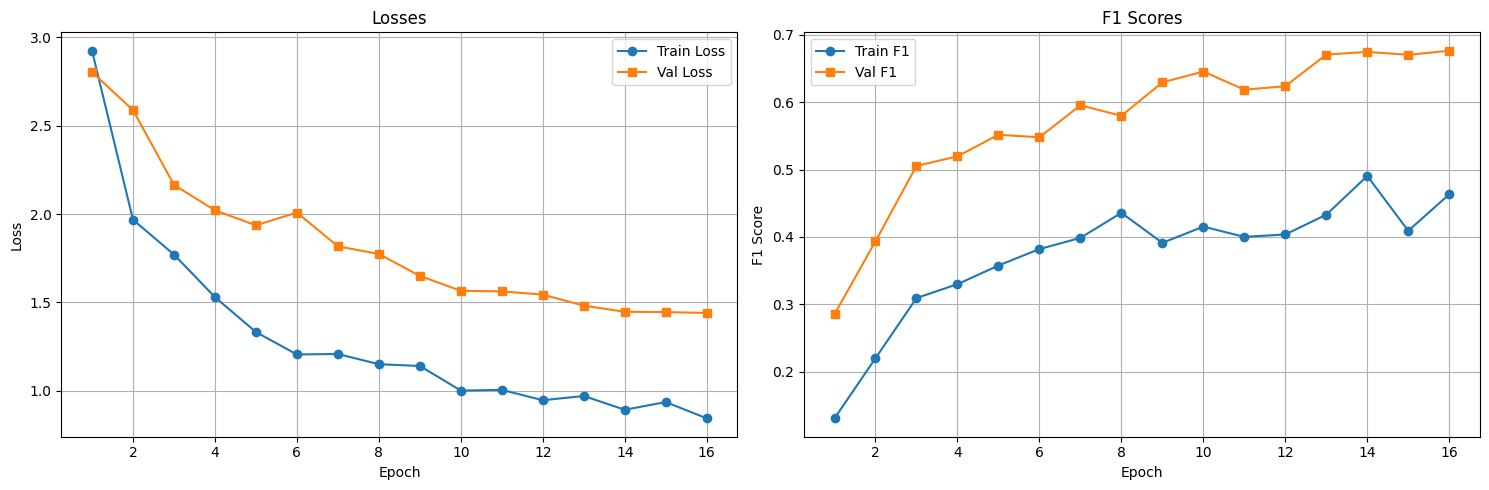

In [60]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [61]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:01<00:00,  9.97it/s]

Submission saved: subs/submission_simplecnn_aug_custom_1_no_thr_sampler_off_weights_off_mixup_on_bs_128.csv


simple_cnn: class_threshold = None, use_sampler = False, use_class_weights = False, use_mixup = False

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_1'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = None  # None - отключено, число - порог
num_classes = len(label_encoder.classes_)
use_sampler = False # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = False # взвешенная функция потерь
use_mixup = False # MixUp аугментация
mixup_alpha = 0.2 # коэффициент смешивания двух изображений
batch_size = 128  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 16

In [63]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: off


In [64]:
# Модель
model_simple_cnn = SimpleCnn(n_classes=num_classes).to(DEVICE).float()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr=1e-3)

# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Обычная CrossEntropyLoss


In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model_simple_cnn,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.8250 on epoch 15

Training on cuda

Epoch 1/16


Train Loss: 2.7331 | F1: 0.2319
Val   Loss: 2.1615 | F1: 0.4186
Best F1!

Epoch 2/16


Train Loss: 1.8662 | F1: 0.4899
Val   Loss: 1.5831 | F1: 0.5728
Best F1!

Epoch 3/16


Train Loss: 1.3808 | F1: 0.6236
Val   Loss: 1.2428 | F1: 0.6695
Best F1!

Epoch 4/16


Train Loss: 1.0709 | F1: 0.7025
Val   Loss: 1.0609 | F1: 0.7102
Best F1!

Epoch 5/16


...

Train Loss: 0.3538 | F1: 0.9029
Val   Loss: 0.7714 | F1: 0.8179
Best F1!

Epoch 13/16


Train Loss: 0.3213 | F1: 0.9121
Val   Loss: 0.7509 | F1: 0.8206
Best F1!

Epoch 14/16


Train Loss: 0.2953 | F1: 0.9205
Val   Loss: 0.7710 | F1: 0.8229
Best F1!

Epoch 15/16


Train Loss: 0.2834 | F1: 0.9238
Val   Loss: 0.7580 | F1: 0.8250
Best F1!

Epoch 16/16


Train Loss: 0.2747 | F1: 0.9243
Val   Loss: 0.7564 | F1: 0.8244

Best Validation F1: 0.8250 on epoch 15


Best Validation Loss:   0.7475 (Epoch 11)
Best Validation F1:     0.8250 (Epoch 15)


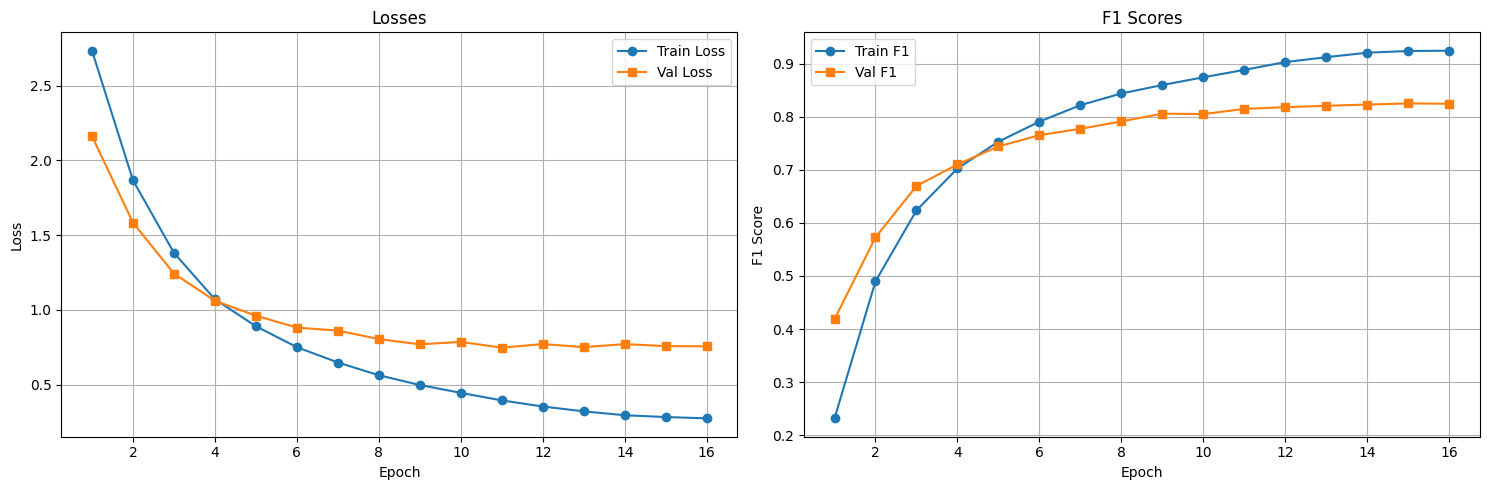

In [66]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [67]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:01<00:00,  9.91it/s]

Submission saved: subs/submission_simplecnn_aug_custom_1_no_thr_sampler_off_weights_off_mixup_off_bs_128.csv


Модель Simple cnn без семплирования, балансировки и с простой аугментацией показа себя лучше более 'навороченной' модели.

### Обучение resnet с различными параметрами

Загрузим предобученную модель ResNet-152 и заменим послений полносвязный слой на слой, подходящий для работы с нашим датасетом (количество классов).

Теперь попробуем несколько вариантов наборов параметров для обучения модели и создания даталоадеров для предобученной на ImageNet v1 модели ResNet-152.

Размер батча изменим с 128 на 64 для экономии памяти. Скорость обучения будет разной для предобученных слоев (lr_backbone) и для нового слоя (lr_head).

#1 Resnet

In [68]:
def build_resnet152(num_classes=num_classes, pretrained=True):
    """
    Создание модели ResNet-152 с настройкой слоев
    """
    if pretrained:
        # Использование предобученных весов ImageNet v1
        model = models.resnet152(weights=models.ResNet152_Weights.IMAGENET1K_V1)
    else:
        model = models.resnet152(weights=None)
    
    # Замена последнего слоя FC
    num_features = model.fc.in_features
    model.fc = nn.Linear(num_features, num_classes)
    
    return model

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_1'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = 70  # None - отключено, число - порог для условной аугментации
num_classes = len(label_encoder.classes_)
use_sampler = True # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = True # взвешенная функция потерь
use_mixup = True # MixUp аугментация
mixup_alpha = 0.2 # коэффициент смешивания двух изображений
batch_size = 64  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 36

In [70]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: on (oversample=2.0)


In [71]:
# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Взвешенная CrossEntropyLoss


In [72]:
# Создание модели
model = build_resnet152(num_classes=num_classes, pretrained=True)
model = model.to(DEVICE)

# Оптимизатор

lr_head = 5e-5      # 1e-4
lr_backbone = 5e-6  # 1e-5
weight_decay = 1e-4

# Разделение параметров для разных learning rates
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": lr_backbone},
    {"params": head_params, "lr": lr_head}
], weight_decay=weight_decay)

In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.9775 on epoch 36

Training on cuda

Epoch 1/36


Train Loss: 2.8640 | F1: 0.2096
Val   Loss: 2.0615 | F1: 0.7801
Best F1!

Epoch 2/36


Train Loss: 1.3831 | F1: 0.4809
Val   Loss: 0.8793 | F1: 0.9129
Best F1!

Epoch 3/36


Train Loss: 0.8724 | F1: 0.4996
Val   Loss: 0.6195 | F1: 0.9287
Best F1!

Epoch 4/36


Train Loss: 0.7662 | F1: 0.5459
Val   Loss: 0.4960 | F1: 0.9436
Best F1!

Epoch 5/36


...

Train Loss: 0.4323 | F1: 0.5268
Val   Loss: 0.2087 | F1: 0.9754
Best F1!

Epoch 33/36


Train Loss: 0.3952 | F1: 0.4898
Val   Loss: 0.1897 | F1: 0.9767
Best F1!

Epoch 34/36


Train Loss: 0.4257 | F1: 0.5188
Val   Loss: 0.2168 | F1: 0.9759

Epoch 35/36


Train Loss: 0.4104 | F1: 0.5259
Val   Loss: 0.1850 | F1: 0.9773
Best F1!

Epoch 36/36


Train Loss: 0.3830 | F1: 0.5385
Val   Loss: 0.1796 | F1: 0.9775
Best F1!

Best Validation F1: 0.9775 on epoch 36


Best Validation Loss:   0.1796 (Epoch 36)
Best Validation F1:     0.9775 (Epoch 36)


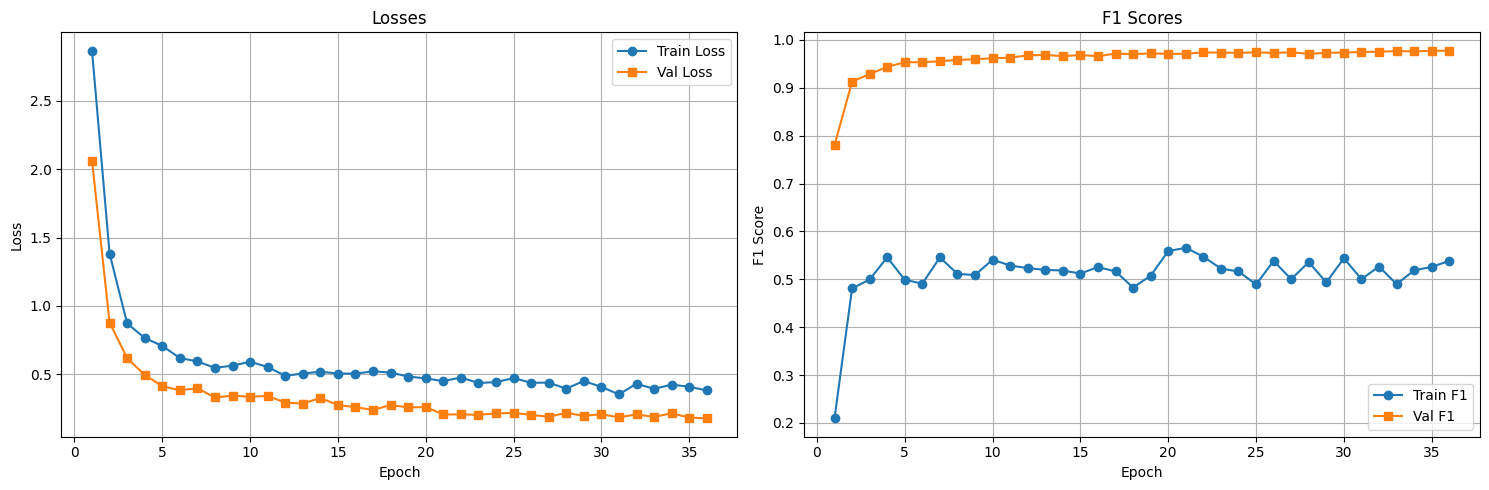

In [74]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [75]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:02<00:00,  5.60it/s]

Submission saved: subs/submission_resnet_aug_custom_1_no_thr_sampler_off_weights_off_mixup_on_bs_128.csv


#2 Resnet

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_1'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = None  # None - отключено, число - порог для условной аугментации
num_classes = len(label_encoder.classes_)
use_sampler = False # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = False # взвешенная функция потерь
use_mixup = True # MixUp аугментация
mixup_alpha = 0.4 # коэффициент смешивания двух изображений
batch_size = 64  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 36

In [77]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: off


In [78]:
# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Обычная CrossEntropyLoss


In [79]:
# Создание модели
model = build_resnet152(num_classes=num_classes, pretrained=True)
model = model.to(DEVICE)

# Оптимизатор

lr_head = 5e-5      # 1e-4
lr_backbone = 5e-6  # 1e-5
weight_decay = 1e-4

# Разделение параметров для разных learning rates
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": lr_backbone},
    {"params": head_params, "lr": lr_head}
], weight_decay=weight_decay)

In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.9834 on epoch 36

Training on cuda

Epoch 1/36


Train Loss: 2.6473 | F1: 0.2374
Val   Loss: 1.4560 | F1: 0.7654
Best F1!

Epoch 2/36


Train Loss: 1.5092 | F1: 0.3947
Val   Loss: 0.7386 | F1: 0.8636
Best F1!

Epoch 3/36


Train Loss: 1.2287 | F1: 0.4602
Val   Loss: 0.4931 | F1: 0.9096
Best F1!

Epoch 4/36


Train Loss: 1.1238 | F1: 0.4606
Val   Loss: 0.4139 | F1: 0.9347
Best F1!

Epoch 5/36


...

Train Loss: 0.6717 | F1: 0.4965
Val   Loss: 0.1469 | F1: 0.9817

Epoch 33/36


Train Loss: 0.6453 | F1: 0.4770
Val   Loss: 0.1282 | F1: 0.9824

Epoch 34/36


Train Loss: 0.6893 | F1: 0.5551
Val   Loss: 0.1315 | F1: 0.9830

Epoch 35/36


Train Loss: 0.6548 | F1: 0.5807
Val   Loss: 0.1226 | F1: 0.9820

Epoch 36/36


Train Loss: 0.6673 | F1: 0.5559
Val   Loss: 0.1197 | F1: 0.9834
Best F1!

Best Validation F1: 0.9834 on epoch 36


Best Validation Loss:   0.1164 (Epoch 25)
Best Validation F1:     0.9834 (Epoch 36)


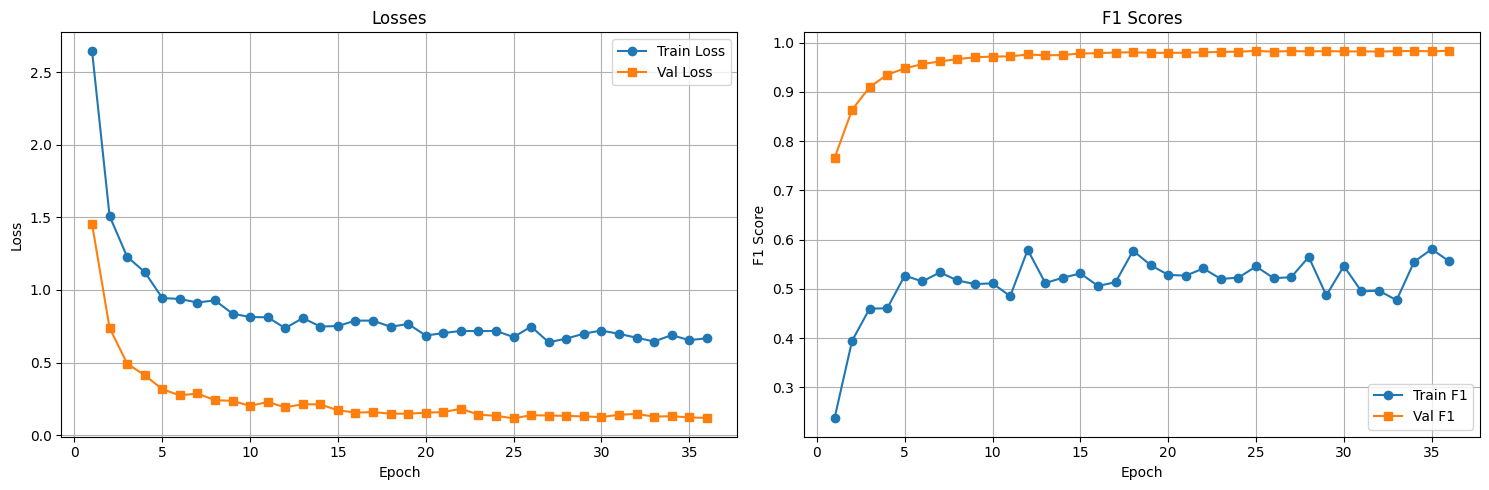

In [81]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [82]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:02<00:00,  5.53it/s]

Submission saved: subs/submission_resnet_aug_custom_1_no_thr_sampler_off_weights_off_mixup_on_bs_128.csv


Уменьшу количество эпох до 26. <br>
Перспективные модели можно будет потом дообучить, так как модели сохраняются по чекпоинтам в процессе обучения.

#3 Resnet

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_1'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = None  # None - отключено, число - порог для условной аугментации
num_classes = len(label_encoder.classes_)
use_sampler = False # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = True # взвешенная функция потерь
use_mixup = False # MixUp аугментация
mixup_alpha = 0.2 # коэффициент смешивания двух изображений
batch_size = 64  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 26

In [84]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: off


In [85]:
# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Взвешенная CrossEntropyLoss


In [86]:
# Создание модели
model = build_resnet152(num_classes=num_classes, pretrained=True)
model = model.to(DEVICE)

# Оптимизатор

lr_head = 5e-5      # 1e-4
lr_backbone = 5e-6  # 1e-5
weight_decay = 1e-4

# Разделение параметров для разных learning rates
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": lr_backbone},
    {"params": head_params, "lr": lr_head}
], weight_decay=weight_decay)

In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.9796 on epoch 26

Training on cuda

Epoch 1/26


Train Loss: 3.5276 | F1: 0.2615
Val   Loss: 2.9765 | F1: 0.6169
Best F1!

Epoch 2/26


Train Loss: 2.4820 | F1: 0.7586
Val   Loss: 1.6547 | F1: 0.8565
Best F1!

Epoch 3/26


Train Loss: 1.2751 | F1: 0.8822
Val   Loss: 0.9333 | F1: 0.9159
Best F1!

Epoch 4/26


Train Loss: 0.6715 | F1: 0.9163
Val   Loss: 0.5624 | F1: 0.9324
Best F1!

Epoch 5/26


...

Train Loss: 0.0102 | F1: 0.9963
Val   Loss: 0.1574 | F1: 0.9780

Epoch 23/26


Train Loss: 0.0096 | F1: 0.9967
Val   Loss: 0.1646 | F1: 0.9771

Epoch 24/26


Train Loss: 0.0088 | F1: 0.9970
Val   Loss: 0.1656 | F1: 0.9782
Best F1!

Epoch 25/26


Train Loss: 0.0129 | F1: 0.9975
Val   Loss: 0.1642 | F1: 0.9771

Epoch 26/26


Train Loss: 0.0064 | F1: 0.9987
Val   Loss: 0.1554 | F1: 0.9796
Best F1!

Best Validation F1: 0.9796 on epoch 26


Best Validation Loss:   0.1519 (Epoch 18)
Best Validation F1:     0.9796 (Epoch 26)


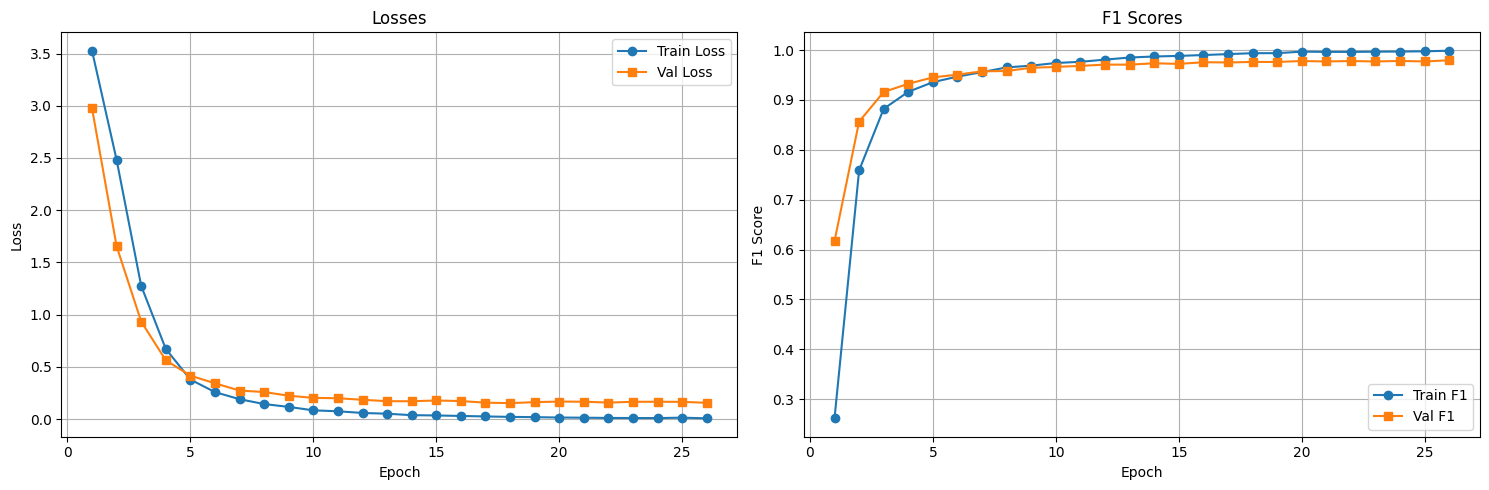

In [88]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [89]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:02<00:00,  5.71it/s]

Submission saved: subs/submission_resnet_aug_custom_1_no_thr_sampler_off_weights_off_mixup_off_bs_128.csv


#4 Resnet

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_1'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = 90  # None - отключено, число - порог для условной аугментации
num_classes = len(label_encoder.classes_)
use_sampler = False # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = True # взвешенная функция потерь
use_mixup = True # MixUp аугментация
mixup_alpha = 0.4 # коэффициент смешивания двух изображений
batch_size = 64  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 26

In [91]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: off


In [92]:
# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Взвешенная CrossEntropyLoss


In [93]:
# Создание модели
model = build_resnet152(num_classes=num_classes, pretrained=True)
model = model.to(DEVICE)

# Оптимизатор

lr_head = 5e-5      # 1e-4
lr_backbone = 5e-6  # 1e-5
weight_decay = 1e-4

# Разделение параметров для разных learning rates
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": lr_backbone},
    {"params": head_params, "lr": lr_head}
], weight_decay=weight_decay)

In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.9683 on epoch 25

Training on cuda

Epoch 1/26


Train Loss: 3.6159 | F1: 0.1101
Val   Loss: 3.1874 | F1: 0.4818
Best F1!

Epoch 2/26


Train Loss: 3.0340 | F1: 0.3098
Val   Loss: 2.1115 | F1: 0.8026
Best F1!

Epoch 3/26


Train Loss: 2.1917 | F1: 0.4273
Val   Loss: 1.2368 | F1: 0.8928
Best F1!

Epoch 4/26


Train Loss: 1.7020 | F1: 0.4372
Val   Loss: 0.9795 | F1: 0.9129
Best F1!

Epoch 5/26


...

Train Loss: 0.8646 | F1: 0.5201
Val   Loss: 0.3880 | F1: 0.9658
Best F1!

Epoch 23/26


Train Loss: 0.8614 | F1: 0.5002
Val   Loss: 0.3442 | F1: 0.9641

Epoch 24/26


Train Loss: 0.8545 | F1: 0.5032
Val   Loss: 0.3504 | F1: 0.9633

Epoch 25/26


Train Loss: 0.7986 | F1: 0.5220
Val   Loss: 0.3153 | F1: 0.9683
Best F1!

Epoch 26/26


Train Loss: 0.8851 | F1: 0.5000
Val   Loss: 0.3299 | F1: 0.9662

Best Validation F1: 0.9683 on epoch 25


Best Validation Loss:   0.3153 (Epoch 25)
Best Validation F1:     0.9683 (Epoch 25)


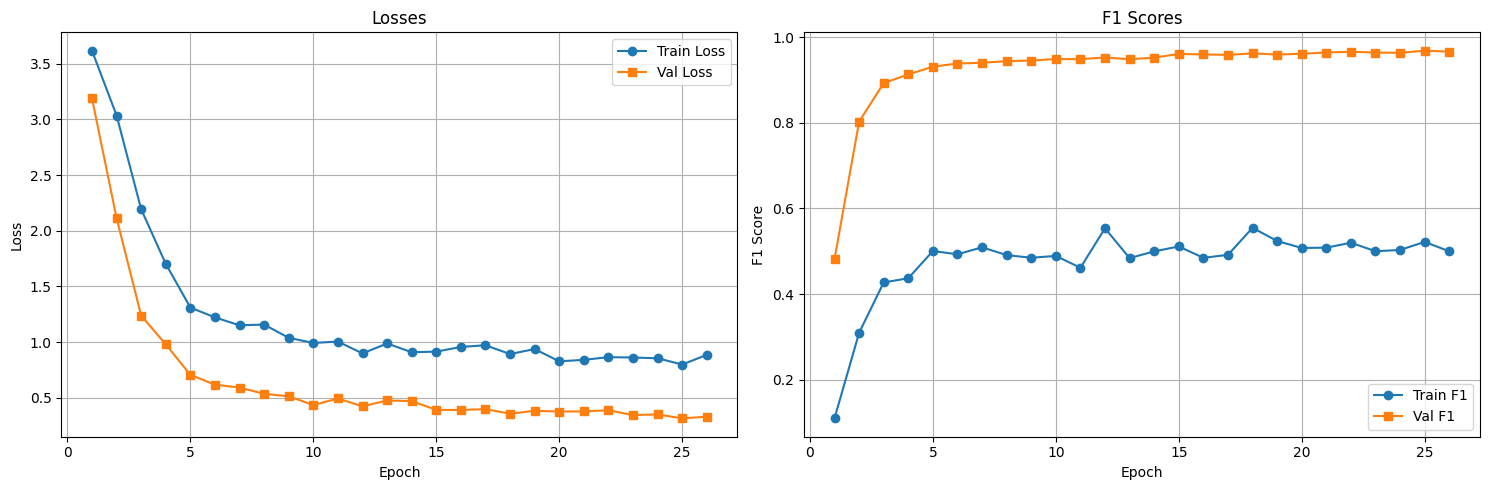

In [95]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [96]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:02<00:00,  5.56it/s]

Submission saved: subs/submission_resnet_aug_custom_1_no_thr_sampler_off_weights_off_mixup_on_bs_128.csv


#5 Resnet

In [ ]:
# Параметры выбора обучения модели и создания даталоадеров
augmentation_type = 'custom_2'  # 'basic', 'custom_1', 'custom_2', 'custom_3', 'custom_4'
class_threshold = 80  # None - отключено, число - порог для условной аугментации
num_classes = len(label_encoder.classes_)
use_sampler = True # семплирование
sampler_oversample = 2.0 # множитель увеличения выборки
use_class_weights = True # взвешенная функция потерь
use_mixup = True # MixUp аугментация
mixup_alpha = 0.2 # коэффициент смешивания двух изображений
batch_size = 64  # 128 (simple_cnn) / 64 (resnet)
num_epochs = 26

In [98]:
# Создания даталоадеров
loaders, class_weights_tensor, class_counts = create_dataloaders(
    train_files, val_files, label_encoder,
    augmentation_type=augmentation_type,
    class_threshold=class_threshold,
    use_sampler=use_sampler,
    sampler_oversample=sampler_oversample,
    batch_size=batch_size
)

Sampler: on (oversample=2.0)


In [99]:
# Функция потерь (с весами или без)
if use_class_weights:
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor.to(DEVICE))
    print('Взвешенная CrossEntropyLoss')
else:
    criterion = nn.CrossEntropyLoss()
    print('Обычная CrossEntropyLoss')

# Scheduler
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

Взвешенная CrossEntropyLoss


In [100]:
# Создание модели
model = build_resnet152(num_classes=num_classes, pretrained=True)
model = model.to(DEVICE)

# Оптимизатор

lr_head = 5e-5      # 1e-4
lr_backbone = 5e-6  # 1e-5
weight_decay = 1e-4

# Разделение параметров для разных learning rates
backbone_params = [p for n, p in model.named_parameters() if not n.startswith("fc.")]
head_params = [p for n, p in model.named_parameters() if n.startswith("fc.")]

optimizer = torch.optim.AdamW([
    {"params": backbone_params, "lr": lr_backbone},
    {"params": head_params, "lr": lr_head}
], weight_decay=weight_decay)

In [ ]:
# Очищаем кэш
torch.cuda.empty_cache()

# Обучение
model, history, model_name = train_model(
    model=model,
    num_epochs=num_epochs,
    loaders=loaders,
    optimizer=optimizer,
    criterion=criterion,
    device=DEVICE,
    scheduler=scheduler,
    use_mixup=use_mixup,
    mixup_alpha=mixup_alpha
)

# Best Validation F1: 0.9757 on epoch 26

Training on cuda

Epoch 1/26


Train Loss: 2.8617 | F1: 0.2101
Val   Loss: 2.0416 | F1: 0.7774
Best F1!

Epoch 2/26


Train Loss: 1.4216 | F1: 0.4773
Val   Loss: 0.9057 | F1: 0.9058
Best F1!

Epoch 3/26


Train Loss: 0.8832 | F1: 0.5023
Val   Loss: 0.6144 | F1: 0.9316
Best F1!

Epoch 4/26


Train Loss: 0.7516 | F1: 0.5460
Val   Loss: 0.4930 | F1: 0.9433
Best F1!

Epoch 5/26


...

Train Loss: 0.4855 | F1: 0.5485
Val   Loss: 0.2016 | F1: 0.9748
Best F1!

Epoch 23/26


Train Loss: 0.4367 | F1: 0.5221
Val   Loss: 0.2271 | F1: 0.9746

Epoch 24/26


Train Loss: 0.4495 | F1: 0.5190
Val   Loss: 0.2549 | F1: 0.9706

Epoch 25/26


Train Loss: 0.4849 | F1: 0.4921
Val   Loss: 0.2606 | F1: 0.9731

Epoch 26/26


Train Loss: 0.4409 | F1: 0.5386
Val   Loss: 0.2401 | F1: 0.9757
Best F1!

Best Validation F1: 0.9757 on epoch 26


Best Validation Loss:   0.2016 (Epoch 22)
Best Validation F1:     0.9757 (Epoch 26)


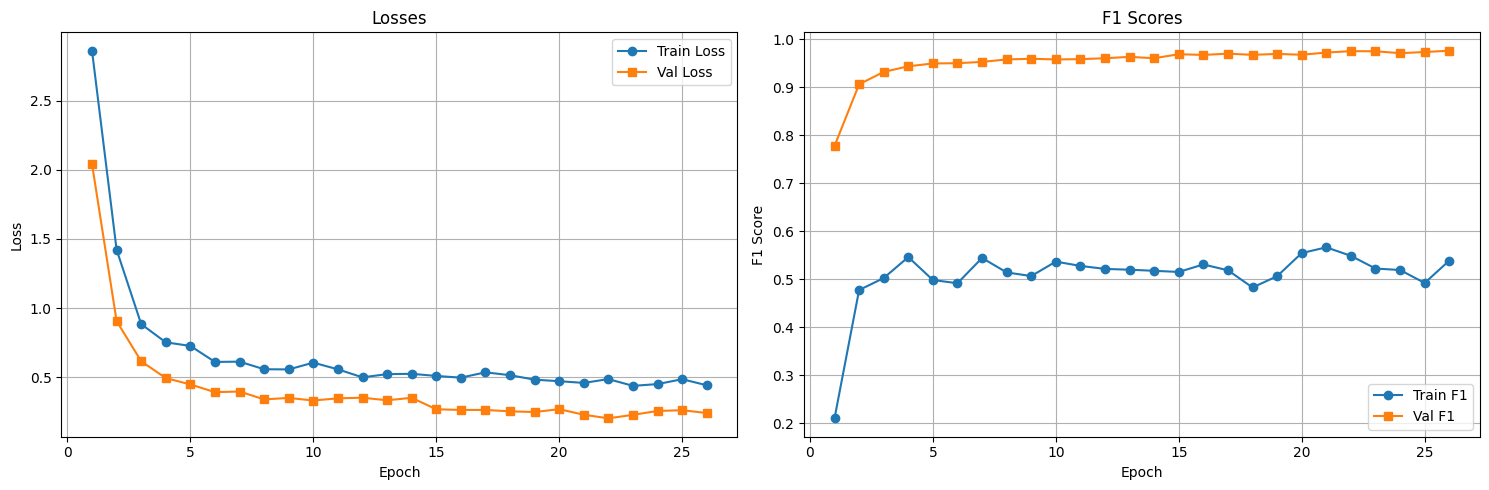

In [102]:
# Визуализация результатов

plot_metrics(history, num_epochs)

plt.show();

In [103]:
# Сохранение сабмита
submission = make_submission(model, test_files, label_encoder, model_name, DEVICE)

Test: 100%|██████████| 16/16 [00:02<00:00,  5.72it/s]

Submission saved: subs/submission_resnet_aug_custom_1_no_thr_sampler_off_weights_off_mixup_on_bs_128.csv


# Вывод

Лучше всего показала себя предобученная на ImageNet v1 модель **ResNet-152 (#2)**. <br>
Дообучивать другие модели, с количеством эпох = 26 не обязательно. На соответсвующих моедли #2 эпохах они показывются результат хуже. <br><br>
**Параметры лучшей модели:**

| Параметр | Значение | Пояснение |
|----------|----------|-----------|
| augmentation_type | 'custom_1' | первый набор аугментаций (самые простые) |
| class_threshold | None | без условной аугментации |
| use_sampler | False | без семплирования |
| sampler_oversample | 2.0 | не используется, так как без семплирования |
| use_class_weights | False | без взвешенной функции потерь |
| use_mixup | True | MixUp аугментация |
| mixup_alpha | 0.4 | MixUp смешивание изображений классов |
| batch_size | 64 | размер батча 64 |
| num_epochs | 36 | количество эпох 36 |
| optimizer | AdamW | с реализацией weight decay |
| scheduler | CosineAnnealingLR | плавное уменьшение learning rate |
| lr_backbone | 5e-6 | скорость обучения предобученной части |
| lr_head | 5e-5 | скорость обучения нового слоя |

Так как модель ResNet-152 уже предобучена, она и так очень хорошо выделяет признаки. Следовательно сильных аугментаций и балансировок ей не нужно, справляется хорошо и без них. <br><br>
**Лучший скор: Best Validation F1: 0.9834 on epoch 36, Loss: 0.1197.**

*На тесте в kaggle тоже хороший скор ☺*